In [36]:
!pip install islp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from ISLP import load_data

df = load_data("Smarket")

# Statistical inference
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Machine Learning & metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore') 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Data: S&P 500 (Smarket)
dataset `Smarket`.
* **Target:** `Direction` (Up/Down).
* **Features:** `Lag1`...`Lag5` (Retornos días previos) y `Volume`.

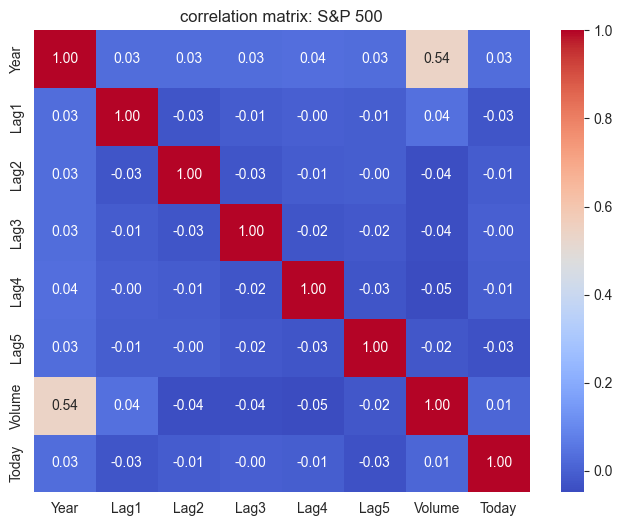

In [37]:
# Download from official ISLP repository
df = load_data("Smarket")
# Feature Engineering: Convertir Target a Binario (1=Up, 0=Down)
df['Direction_Bin'] = df['Direction'].map({'Up': 1, 'Down': 0})

# Correlation Analysis
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("correlation matrix: S&P 500")
plt.show()

## Logistic Regression (Inferencial approach)

We use the **Logit** function to transform the linear output into probabilities:$$p(X) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}}$$

We look for statistical significance (P-values) in the coefficients.

In [38]:
df['Direction_Bin'] = df['Direction_Bin'].astype(int)
# Full model adjustment
formula = 'Direction_Bin ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume'
model_logit = smf.logit(formula=formula, data=df).fit()

print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.691034
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction_Bin   No. Observations:                 1250
Model:                          Logit   Df Residuals:                     1243
Method:                           MLE   Df Model:                            6
Date:                Tue, 17 Feb 2026   Pseudo R-squ.:                0.002074
Time:                        20:04:52   Log-Likelihood:                -863.79
converged:                       True   LL-Null:                       -865.59
Covariance Type:            nonrobust   LLR p-value:                    0.7319
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1260      0.241     -0.523      0.601      -0.598       0.346
Lag1          -0.0731      0.

## Comparative Prediction Pipeline

To evaluate generative vs. discriminative models, we perform a **Temporal Split**:
* **Train:** 2001-2004
* **Test:** 2005

We do not use random train_test_split to avoid temporary data leakage.

In [39]:
# Divide the data respecting the temporal order
train = df[df['Year'] < 2005]
test = df[df['Year'] == 2005]

# We select predictors and response
features = ['Lag1', 'Lag2']
X_train = train[features]
y_train = train['Direction']

X_test = test[features]
y_test = test['Direction']

print(f"Train: {X_train.shape[0]} days (2001-2004)")
print(f"Test: {X_test.shape[0]} days (2005)")

Train: 998 days (2001-2004)
Test: 252 days (2005)


## Comparison of Generative Models
We will train three classic models and compare their effectiveness on the test set (2005).

* **LDA:** Assumes normal distributions and constant variance. (Linear frontier).
* **QDA:** Assumes normal distributions and variable variance. (Curved frontier).
* **Naive Bayes:** Assumes independence between lags.


In [40]:
# define models 
models = {
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    # trainning
    model.fit(X_train, y_train)
    # predict
    preds = model.predict(X_test)
    # evaluate
    acc = accuracy_score(y_test, preds)
    results.append({'Model': name, 'Accuracy': acc})
    
    # Print confusion matrix for quick analysis
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.2%}")
    # simple matrix
    cm = pd.crosstab(y_test, preds, rownames=['Real'], colnames=['predict'])
    print(cm)
    print("\n")

# save
results_df = pd.DataFrame(results)

--- LDA ---
Accuracy: 55.95%
predict  Down   Up
Real              
Down       35   76
Up         35  106


--- QDA ---
Accuracy: 59.92%
predict  Down   Up
Real              
Down       30   81
Up         20  121


--- Naive Bayes ---
Accuracy: 59.52%
predict  Down   Up
Real              
Down       29   82
Up         20  121




## K-Nearest Neighbors (KNN)
KNN is different: it does not assume distributions, it only looks at neighbors. Critical Point: Since KNN calculates distances, if the variables have different scales, the model fails. Although Lag1 and Lag2 are on the same scale here, it is good professional practice to always standardize.

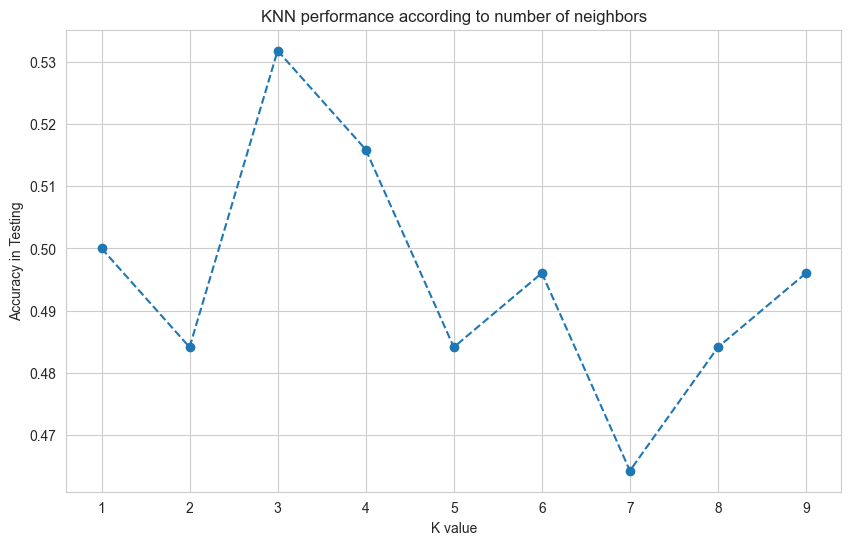

Best Accuracy in KNN: 53.17% with K=3


In [41]:
# Standardize the data (Mean 0, Variance 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # OJO: Transformamos test con los parámetros de train

# looking for the best K (manual hyperparameter tuning)
k_values = range(1, 10)
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    knn_accuracies.append(acc)

# k performance
plt.plot(k_values, knn_accuracies, marker='o', linestyle='--')
plt.xlabel("K value")
plt.ylabel("Accuracy in Testing")
plt.title("KNN performance according to number of neighbors")
plt.show()

print(f"Best Accuracy in KNN: {max(knn_accuracies):.2%} with K={k_values[np.argmax(knn_accuracies)]}")

# We add the best KNN to our results
results_df = pd.concat([results_df, pd.DataFrame([{'Model': 'KNN (Best K)', 'Accuracy': max(knn_accuracies)}])], ignore_index=True)

## Conclusion and Summary
We compiled all the results to decide which model we would take into production (or use for investment).

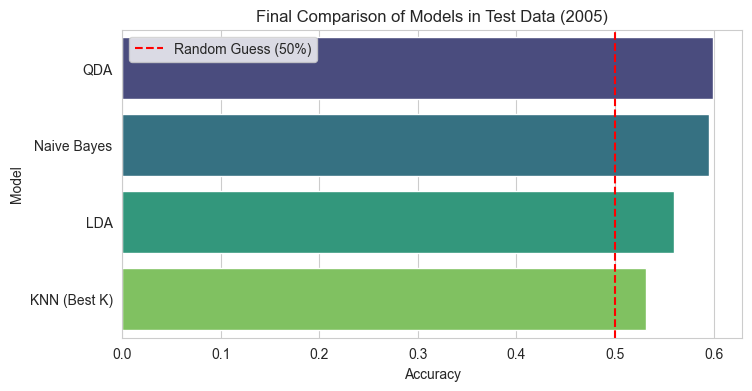

,Model,Accuracy
1,QDA,0.599206
2,Naive Bayes,0.595238
0,LDA,0.559524
3,KNN (Best K),0.531746


In [42]:
# order by accuracy
final_summary = results_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Accuracy', y='Model', data=final_summary, palette='viridis')
plt.title("Final Comparison of Models in Test Data (2005)")
plt.axvline(0.5, color='r', linestyle='--', label='Random Guess (50%)') # baseline
plt.legend()
plt.show()

display(final_summary)

---

## Regresión Logística

### Fundamento Teórico

La **regresión logística** es un método de clasificación que modela la probabilidad de que una observación pertenezca a una clase particular usando la **función logística** (sigmoid).

#### 📐 Función Logística (Sigmoid)

$$\sigma(z) = \frac{1}{1 + e^{-z}} = \frac{e^z}{1 + e^z}$$

**Propiedades importantes:**
- Rango: $(0, 1)$ 
- Forma de "S"
- $\sigma(0) = 0.5$
- $\sigma(-\infty) = 0$ y $\sigma(+\infty) = 1$
- Simétrica: $\sigma(-z) = 1 - \sigma(z)$

#### 📊 Modelo Logístico para Clasificación Binaria

Modelamos la probabilidad de la clase positiva ($Y=1$):

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + ... + \beta_p X_p)}}$$

O de forma compacta:

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta^T X)}}$$

#### 🎲 Odds y Log-Odds (Logit)

**Odds** (probabilidad de éxito vs fracaso):

$$\text{odds}(X) = \frac{P(Y=1|X)}{P(Y=0|X)} = \frac{P(Y=1|X)}{1-P(Y=1|X)} = e^{\beta_0 + \beta^T X}$$

**Log-Odds (Logit)** 

$$\log\left(\frac{P(Y=1|X)}{1-P(Y=1|X)}\right) = \beta_0 + \beta^T X$$

**Interpretación de coeficientes:**
- $\beta_j > 0$: Incremento en $X_j$ aumenta probabilidad de $Y=1$
- $\beta_j < 0$: Incremento en $X_j$ disminuye probabilidad de $Y=1$
- $e^{\beta_j}$: **Odds ratio** - multiplicador del odds por cada unidad de incremento en $X_j$

#### 🎯 Estimación de Parámetros: Maximum Likelihood

Los parámetros $\beta$ se estiman maximizando la **log-likelihood**:

$$\ell(\beta) = \sum_{i=1}^{n} \left[ y_i \log(p(x_i)) + (1-y_i)\log(1-p(x_i)) \right]$$

Donde $p(x_i) = P(Y=1|X=x_i)$

**No tiene solución cerrada** → se usa optimización numérica (Newton-Raphson, IRLS)

#### 🔄 Clasificación Multiclase: Softmax Regression

Para $K > 2$ clases, usamos **multinomial logistic regression**:

$$P(Y=k|X) = \frac{e^{\beta_k^T X}}{\sum_{l=1}^{K} e^{\beta_l^T X}}$$

Esta es la **función softmax** - generalización de la función logística.

---


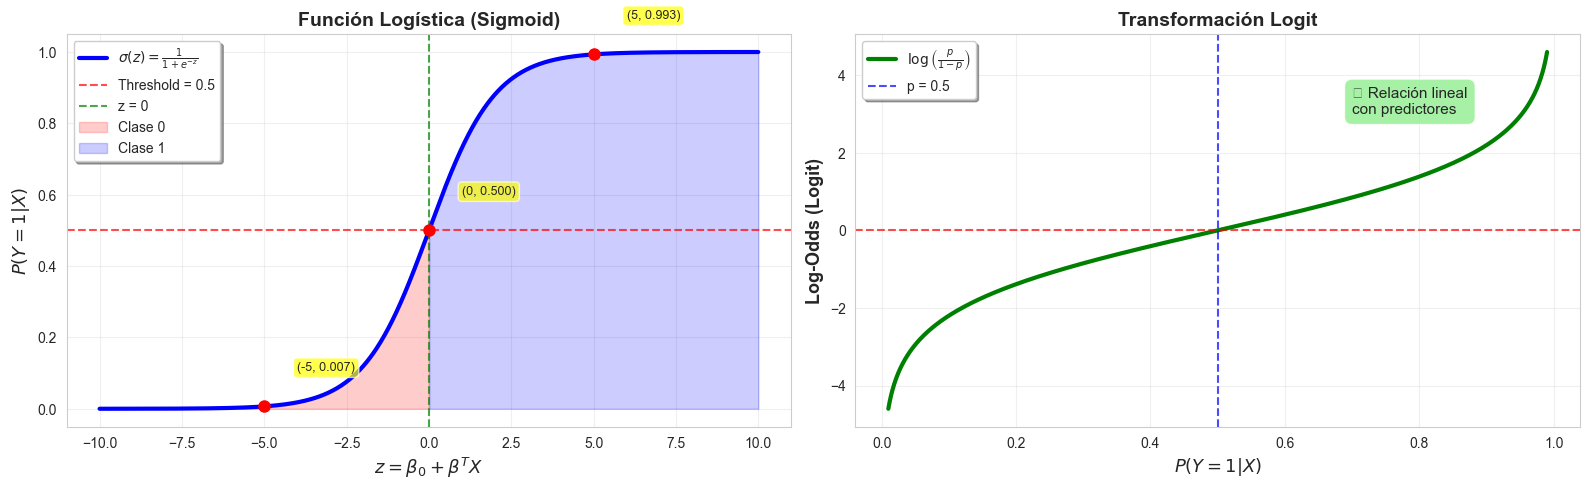

══════════════════════════════════════════════════════════════════════
INTERPRETATION OF THE LOGISTIC FUNCTION
══════════════════════════════════════════════════════════════════════

1. The sigmoid function transforms any real value z into probability (0, 1)

2. The point z=0 corresponds to P=0.5 (default decision threshold)

3. The logit transformation makes the relationship linear with the predictors

4. This allows standard optimization techniques to be used to find β

══════════════════════════════════════════════════════════════════════


In [44]:
# VISUALIZACIÓN DE LA FUNCIÓN LOGÍSTICA (SIGMOID)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# data for the curve 
z = np.linspace(-10, 10, 1000)
prob = sigmoid(z)

# visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Sigmoid Function 

axes[0].plot(z, prob, 'b-', linewidth=3, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Threshold = 0.5')
axes[0].axvline(x=0, color='green', linestyle='--', alpha=0.7, label='z = 0')
axes[0].fill_between(z, 0, prob, where=(z < 0), alpha=0.2, color='red', label='Clase 0')
axes[0].fill_between(z, 0, prob, where=(z >= 0), alpha=0.2, color='blue', label='Clase 1')
axes[0].set_xlabel(r'$z = \beta_0 + \beta^T X$', fontsize=13, fontweight='bold')
axes[0].set_ylabel(r'$P(Y=1|X)$', fontsize=13, fontweight='bold')
axes[0].set_title('Función Logística (Sigmoid)', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=10, frameon=True, shadow=True)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([-0.05, 1.05])

# key points 
key_points = [(-5, sigmoid(-5)), (0, sigmoid(0)), (5, sigmoid(5))]
for z_val, p_val in key_points:
    axes[0].plot(z_val, p_val, 'ro', markersize=8)
    axes[0].annotate(f'({z_val:.0f}, {p_val:.3f})', 
                    xy=(z_val, p_val), 
                    xytext=(z_val+1, p_val+0.1),
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))


# Logit (Log-Odds)
p_range = np.linspace(0.01, 0.99, 1000)
logit = np.log(p_range / (1 - p_range))

axes[1].plot(p_range, logit, 'g-', linewidth=3, 
            label=r'$\log\left(\frac{p}{1-p}\right)$')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[1].axvline(x=0.5, color='blue', linestyle='--', alpha=0.7, label='p = 0.5')
axes[1].set_xlabel(r'$P(Y=1|X)$', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log-Odds (Logit)', fontsize=13, fontweight='bold')
axes[1].set_title('Transformación Logit', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=10, frameon=True, shadow=True)
axes[1].grid(True, alpha=0.3)

# Anotar que es lineal
axes[1].text(0.7, 3, '📈 Relación lineal\ncon predictores', 
            fontsize=11, bbox=dict(boxstyle='round,pad=0.5', 
            facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

print("" + "═"*70)
print("INTERPRETATION OF THE LOGISTIC FUNCTION")
print("═"*70)
print("""
1. The sigmoid function transforms any real value z into probability (0, 1)

2. The point z=0 corresponds to P=0.5 (default decision threshold)

3. The logit transformation makes the relationship linear with the predictors

4. This allows standard optimization techniques to be used to find β
""")
print("═"*70)